# ToBigs 정규세션 5주차 XAI 과제


# 1. Lime

In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=88650656417e9ce72455ece2a0ab87301e2b48e365e49a3919e10eaa643837d9
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


### LIME (Local Interpretable Model-agnostic Explanations) 실습
LIME은 모델의 종류와 상관없이(Model-agnostic) 특정 데이터 포인트의 예측 결과를 국소적으로(Local) 설명하는 기법입니다.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular

# 1. 데이터 로드 (유방암 데이터셋)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [3]:
# features
print(X.info())
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 분류 모델 생성 및 학습 (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# LIME Explainer 초기화
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=data.feature_names,
    class_names=data.target_names,
    mode='classification'
)

# 특정 데이터 샘플에 대해 설명 생성
# 테스트 셋의 첫 번째 데이터를 대상으로 설명 -> local explanation
i = 0
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=rf_model.predict_proba,
    num_features=5 # 상위 5개 주요 feature만
)

# 결과 시각화
print(f'실제 라벨: {data.target_names[y_test[i]]}')
print(f'모델의 예측 확률: {rf_model.predict_proba(X_test.iloc[[i]])}')

# 노트북 내에서 시각화 결과 출력
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

실제 라벨: benign
모델의 예측 확률: [[0.03 0.97]]


Q1. LIME의 핵심 동작 과정에 대해서 서술해주세요.

답:

LIME은 먼저 설명하고 싶은 샘플 하나를 정한 뒤, 그 샘플 주변에 비슷하지만 조금씩 값이 달라진 가짜 샘플들을 많이 만든다. 그다음 원래의 복잡한 모델에 이 샘플들을 넣어서 예측값이 어떻게 흔들리는지 확인한다. 여기서 중요한 건 원본 샘플과 얼마나 가까운지에 따라 가중치를 다르게 주는 점이다. 원본에 가까운 샘플에서 나온 예측 변화는 크게 보고, 멀리 떨어진 샘플은 덜 믿는다. 이렇게 모은 결과를 바탕으로 단순한 선형모델 같은 surrogate model을 그 샘플 주변에만 맞춰서, 어떤 feature가 예측을 올렸고 어떤 feature가 내렸는지 해석한다. 결국 LIME은 전체 모델을 한 번에 설명하려는 게 아니라, 특정 예측 하나를 국소적으로 뜯어보는 방식이라고 보면 된다.

Q2. LIME model에서의 surrogate model의 역할을 설명해주세요.

답:

surrogate model의 역할은 복잡한 원래 모델을 완전히 대체하는 게 아니라, 특정 샘플 근처에서만 잠깐 흉내 내는 데 있다. 원래 모델이 랜덤포레스트든 신경망이든 내부 구조가 복잡하면 사람이 바로 이해하기 어렵다. 그래서 LIME은 그 주변에서의 입력-출력 관계만 따로 떼어 단순한 모델로 근사하고, 그 단순한 모델의 계수나 규칙을 설명으로 사용한다. 쉽게 말해 블랙박스의 행동을 사람이 읽을 수 있는 언어로 번역해 주는 통역기 역할이다. 다만 이 모델은 어디까지나 local approximation이라서, 해당 샘플 주변에서는 유용하지만 전체 데이터 전반의 동작을 대표한다고 보면 안 된다.

---

#2. SHAP

In [5]:
!pip install shap

### SHAP (SHapley Additive exPlanations)
SHAP은 게임 이론의 Shapley Value를 기반으로, 각 특성이 모델의 예측값에 얼마나 기여했는지를 수치화하여 설명하는 기법입니다.

--- 전체 데이터의 특성 중요도 (Summary Plot) ---


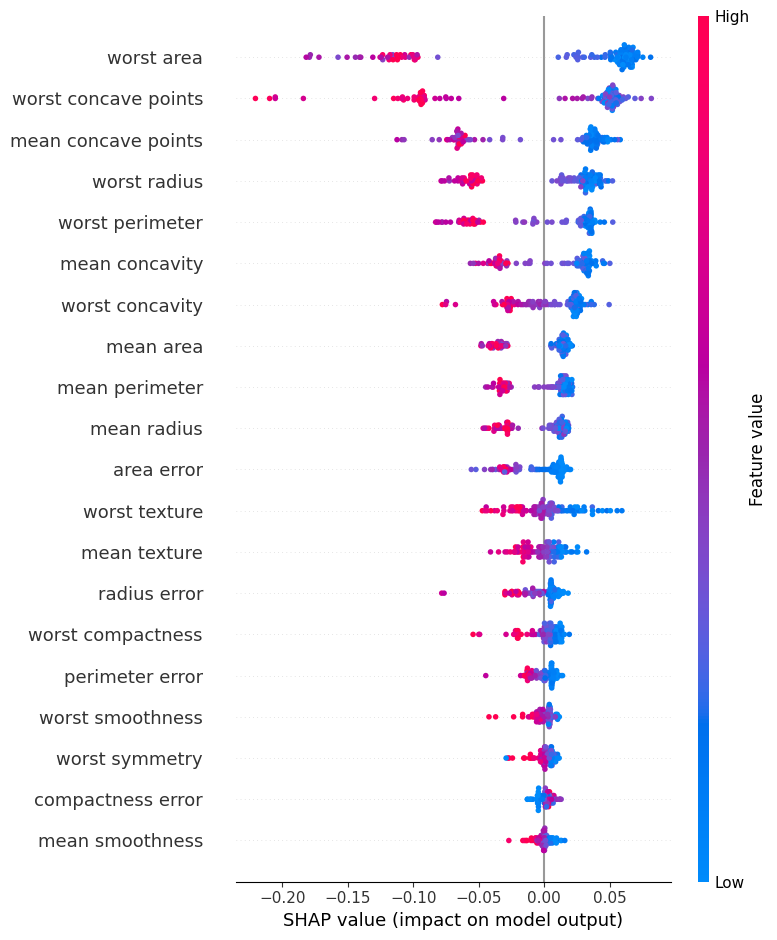

In [6]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP Explainer 초기화, ML 모델을 argument로
explainer_shap = shap.TreeExplainer(rf_model)

# SHAP Value 계산
shap_values = explainer_shap.shap_values(X_test)

# 결과 시각화 준비
if isinstance(shap_values, list):

    target_shap_values = shap_values[1]
    base_value = explainer_shap.expected_value[1]
else:
    if len(shap_values.shape) == 3:
        target_shap_values = shap_values[:, :, 1]
        base_value = explainer_shap.expected_value[1]
    else:
        target_shap_values = shap_values
        base_value = explainer_shap.expected_value

# Summary plot -> feature importance
print("--- 전체 데이터의 특성 중요도 (Summary Plot) ---")
shap.summary_plot(target_shap_values, X_test)


Q3. SHAP Value가 양수인 특성과 음수인 특성은 각각 예측 결과에 어떤 영향을 주는지 서술하세요.

답:

SHAP value의 부호는 기준점인 base value에서 예측이 어느 방향으로 움직였는지를 보여준다. 양수인 feature는 선택한 클래스의 예측값을 base value보다 더 크게 밀어 올린다. 반대로 음수인 feature는 그 클래스의 예측값을 깎아내리거나 다른 클래스 쪽으로 예측이 기울게 만든다. 예를 들어 지금처럼 이진 분류에서 class 1 기준 SHAP 값을 보고 있다면, 양수는 class 1로 판단할 가능성을 높인 요인이고 음수는 그 가능성을 낮춘 요인이다. 그래서 SHAP은 단순히 중요도만 말해 주는 게 아니라, 그 feature가 예측에 플러스였는지 마이너스였는지까지 같이 보여준다는 점이 핵심이다.

Q4. 기존 Tree 기반 ML Model(RF)에서 사용하는 entropy 혹은 geni index 기반 feature importance와 SHAP의 feature importance의 차이점을 서술하세요.

답:

랜덤포레스트에서 흔히 보는 feature importance는 학습 과정에서 어떤 변수가 불순도를 얼마나 많이 줄였는지를 전체 트리 기준으로 합산한 값이다. 그래서 전역적으로 어떤 변수가 자주, 크게 분할에 기여했는지는 볼 수 있지만, 개별 샘플 하나에 대해 왜 그런 예측이 나왔는지까지는 잘 드러나지 않는다. 또 연속형 변수나 분할 경우의 수가 많은 변수에 importance가 다소 유리하게 잡히는 편향도 생길 수 있다. 반면 SHAP은 각 샘플마다 feature가 예측값에 얼마나 기여했는지를 샤플리 값으로 계산하므로 local explanation이 가능하고, 여러 샘플에 대해 평균을 내면 global importance로도 확장할 수 있다. 무엇보다 SHAP은 중요도의 크기뿐 아니라 방향성까지 제공해서, 어떤 feature가 예측을 올렸는지 내렸는지 해석이 훨씬 구체적이다.

---

# 3. Grad-CAM

### Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM은 CNN 기반의 딥러닝 모델이 이미지의 어떤 영역을 보고 특정 클래스로 분류했는지를 중요도에 따라 히트맵(Heatmap) 형태로 시각화하는 기법입니다. 특성 맵(Feature Map)에 흐르는 그래디언트 정보를 사용하여 가중치를 계산합니다.

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:16<00:00, 33.3MB/s]


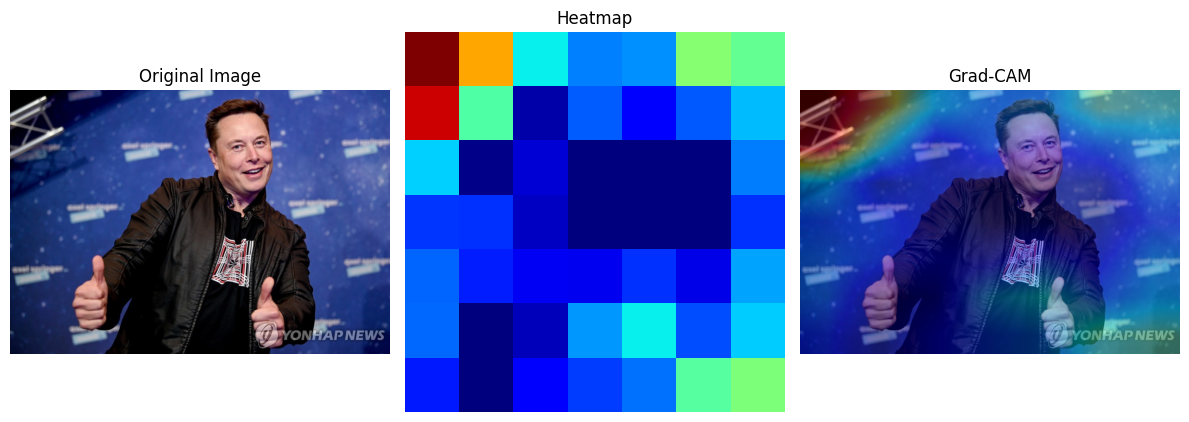

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO

# 1. 사전 학습된 모델 로드 (VGG16)
# weights 매개변수를 사용하여 최신 방식으로 로드합니다.
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()

# 그래디언트와 특성 맵을 저장할 변수
gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# 마지막 컨볼루션 층에 훅 등록 (VGG16의 경우 features의 30번 레이어)
target_layer = model.features[30]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# 2. 이미지 로드 및 전처리
url = 'https://img2.yna.co.kr/photo/etc/epa/2020/12/02/PEP20201202052601055_P4.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

# 3. 모델 예측 및 Grad-CAM 계산
output = model(input_tensor)
pred_index = output.argmax(dim=1).item()

# 역전파 수행
model.zero_grad()
output[0, pred_index].backward()

# 4. Grad-CAM 히트맵 생성
# 글로벌 평균 풀링 (GAP)을 통한 가중치 미분값 계산
weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

# 특성 맵과 가중치 결합
heatmap = torch.sum(weights * activations, dim=1).squeeze()
heatmap = F.relu(heatmap) # ReLU 적용 (양의 영향만 고려)

# 0~1 사이 정규화
if torch.max(heatmap) != 0:
    heatmap /= torch.max(heatmap)
heatmap = heatmap.detach().cpu().numpy()

# 5. 결과 시각화
img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

# 히트맵 리사이즈 및 컬러맵 적용
heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# 원본과 합성 (Bayer 변환 고려)
superimposed_img = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB), 0.4, 0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Heatmap')
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Grad-CAM')
plt.imshow(superimposed_img)
plt.axis('off')

plt.tight_layout()
plt.show()

Q5. Grad-CAM에서 마지막 컨볼루션 층(Last Conv Layer)의 정보를 사용하는 이유는 무엇인가요?

답:

마지막 컨볼루션 층은 공간 정보와 의미 정보를 동시에 어느 정도 유지하고 있는 지점이라서 Grad-CAM에 가장 잘 맞는다. 너무 앞단의 층을 쓰면 엣지나 질감 같은 저수준 정보는 풍부하지만, 그 정보가 특정 클래스와 직접 연결되지는 않는 경우가 많다. 반대로 완전연결층에 가까워질수록 분류에는 직접 연결되지만, 어디를 봤는지에 대한 2차원 위치 정보가 거의 사라진다. 마지막 컨볼루션 층은 이 둘의 타협점이라서, 모델이 무엇을 보고 판단했는지 위치 기반으로 시각화하기 좋다. 그래서 Grad-CAM은 해당 층의 activation map과 gradient를 결합해 클래스별 heatmap을 만든다.

Q6. Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델 판단에 어떤 의미를 갖는지 서술하세요.

답:

붉게 표시되는 영역은 선택한 클래스의 점수를 높이는 데 상대적으로 크게 기여한 부분이라고 해석할 수 있다. 다시 말해 모델이 그 클래스로 판단할 때 강하게 참고한 시각적 단서가 모여 있는 영역이다. 예를 들어 동물 사진이라면 얼굴, 귀, 털 무늬처럼 구분력이 큰 부분이 붉게 나올 수 있다. 다만 붉다고 해서 무조건 사람이 보기에도 가장 중요한 객체 경계와 정확히 일치하는 것은 아니다. 모델은 배경의 특정 패턴이나 주변 문맥 같은 엉뚱한 단서에도 의존할 수 있기 때문에, 이 영역은 ‘모델이 중요하게 봤다’는 뜻이지 ‘정답 객체 그 자체’라는 뜻은 아니다.

Q7. Grad-CAM 으로 시각화 한 heatmap이 과연 이미지의 중요한 객체를 담고 있는지 서술하세요. 만약 아니라면 본인이 생각하는 이유를 작성해주세요.

답:

항상 그렇다고 보기는 어렵다. Grad-CAM heatmap은 모델이 분류에 활용한 단서를 보여주는 데는 꽤 유용하지만, 그 단서가 우리가 생각하는 핵심 객체 전체를 충실하게 담는다고 보장하지는 않는다. 실제로는 객체 전체보다도 일부 discriminative part만 진하게 잡히는 경우가 많고, 배경이나 조명 같은 우연한 상관관계가 함께 강조되기도 한다. 또 마지막 conv layer의 해상도가 낮아서 heatmap이 본질적으로 거칠게 보일 수밖에 없고, 어느 레이어를 기준으로 삼았는지에 따라서도 결과가 달라진다. 그래서 Grad-CAM은 ‘모델이 어디를 봤는지’ 확인하는 1차 도구로는 좋지만, 그 자체만으로 모델이 진짜 중요한 객체를 제대로 이해했다고 단정하면 위험하다.

---

## Quantifying Attention Flow in Transformers 논문 실험해보기(Image)


논문에서 제시된 Attention Rollout을 구현해 분석해보겠습니다.

In [8]:
# 이미지 로드 및 전처리
url = 'https://blog.kakaocdn.net/dna/cyD9pn/btsOxFfpiiW/AAAAAAAAAAAAAAAAAAAAAFGiOvHL_qlCUiUiUIg1JagJFnkaarNn8GiOBCO__hEp/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1774969199&allow_ip=&allow_referer=&signature=yWd4YCmf%2B1q9tAkMCHkW0O6PyJQ%3D'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

In [9]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("transformers") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "transformers"])

from transformers import ViTForImageClassification, ViTConfig

# 모델 설정에서 output_attentions를 명시적으로 True로 설정
config = ViTConfig.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", config=config)

device = torch.device("cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)
model.eval()

with torch.no_grad():
    # 모델 호출 시에도 다시 한 번 명시
    outputs = model(input_tensor, output_attentions=True)

# Attention 추출
attentions = outputs.attentions

if attentions is not None:
    pred_label = model.config.id2label[outputs.logits.argmax(dim=1).item()]
    print(f"predicted label: {pred_label}")
    print(f"num_layers: {len(attentions)}")
    print(f"attention shape of one layer: {attentions[0].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

predicted label: football helmet
num_layers: 12
attention shape of one layer: torch.Size([1, 12, 197, 197])


In [10]:
# rollout function
def attention_rollout(attentions):
    """
    attentions:
        tuple/list of attention tensors
        each tensor shape = (B, H, N, N)

    return:
        rollout: (B, N, N)
    """
    batch_size = attentions[0].shape[0]
    num_tokens = attentions[0].shape[-1]
    device = attentions[0].device

    # 초기값: identity 행렬(torch.eye)
    rollout = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)

    for attention in attentions:
        # 1) head fusion: mean(N개의 Attention Head를 어떻게 aggregation 할지, 여기서는 평균)
        attn = attention.mean(dim=1)   # (B, N, N)

        # 2) residual connection 반영(identity matrix를 더함)
        I = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
        attn = attn + I

        # 3) row normalization(행의 합을 1로 맞춰줌)
        attn = attn / attn.sum(dim=-1, keepdim=True)

        # 4) rollout: 계속 곱함
        rollout = torch.bmm(attn, rollout)

    return rollout

In [11]:
with torch.no_grad():
    outputs = model(input_tensor, output_attentions=True)

attentions = outputs.attentions

print("num_layers:", len(attentions))
print("one attention shape:", attentions[0].shape)

num_layers: 12
one attention shape: torch.Size([1, 12, 197, 197])


In [12]:
# Rollout 계산
rollout = attention_rollout(attentions)   # (B, N, N)

# 첫 번째 배치 사용
rollout_map = rollout[0]   # (N, N)

# CLS token -> patch tokens
cls_attention = rollout_map[0, 1:]   # (num_patches,)

In [13]:
# patch map으로 변환
num_patches = cls_attention.shape[0]
grid_size = int(np.sqrt(num_patches))

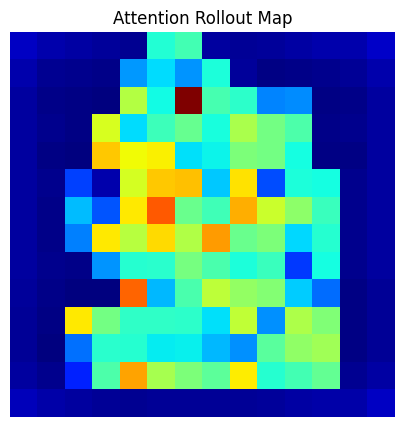

In [14]:
mask = cls_attention.reshape(grid_size, grid_size).detach().cpu().numpy()

# 0~1 정규화
mask = mask - mask.min()
mask = mask / (mask.max() + 1e-8)

# heatmap 시각화
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout Map")
plt.axis("off")
plt.show()


# 원본 이미지 복원(input_tensor가 normalize 되었기 때문에 다시 복원)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
def denormalize_image(img_tensor, mean, std):
    """
    img_tensor: (3, H, W)
    """
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img
img = denormalize_image(input_tensor[0], mean, std)
img = img.permute(1, 2, 0).detach().cpu().numpy()   # (H, W, 3)



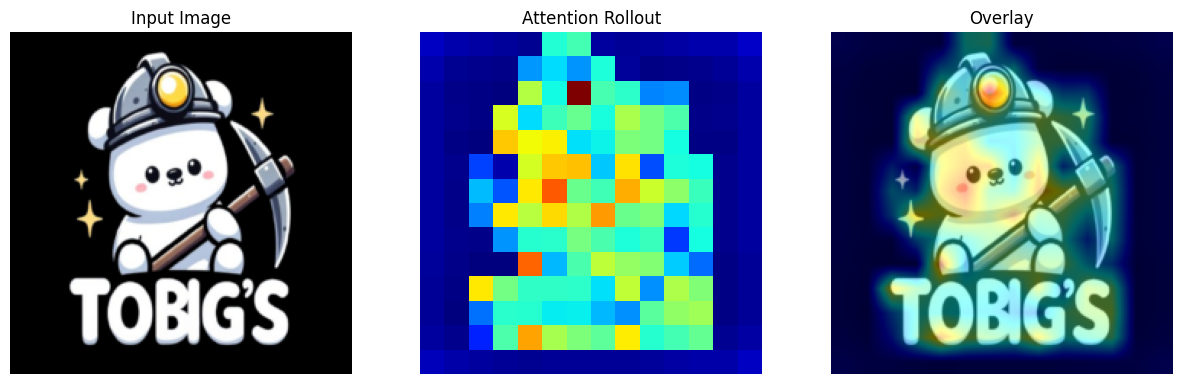

In [15]:
# 그림 시각화
H, W, _ = img.shape
mask_resized = cv2.resize(mask, (W, H))

heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.6 * img + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

Q8. 기존의 Attention Score 기반 explanation 말고 위와 같은 Attention rollout 방법을 사용하는 이유를 알려주세요.

답:

단일 Attention Score만 보면 특정 head, 특정 layer에서 토큰끼리 한 번 연결된 관계만 보는 셈이라 해석이 꽤 단편적이다. 그런데 Transformer는 여러 층을 거치면서 정보가 계속 섞이고, residual connection 때문에 이전 정보도 함께 전달된다. Attention rollout은 이런 누적 효과를 반영해서, 입력 토큰의 정보가 최종 CLS 토큰까지 어떻게 전달되는지를 전체 경로 관점에서 본다. 그래서 한 층의 attention map보다 더 안정적이고 전역적인 설명을 줄 수 있다. 특히 어떤 patch가 최종 분류에 실제로 얼마나 영향력을 남겼는지 보고 싶을 때는 rollout 방식이 raw attention보다 해석력이 높은 편이다.

(Optional) Q9. Attention Score를 기반으로 해석한, Score가 높은 word token 혹은 patch token으로 어떤 방법론을 만들 수 있을까요?(EX. ViT에서 Attention Score가 높은 patch token들을 따로 모아서 세밀한 부분을 구별하는 discriminative features로 사용 등)

답:

충분히 여러 방법론으로 확장할 수 있다. 예를 들어 attention score가 높은 patch만 따로 골라 고해상도 재인코딩을 수행하면, 연산량은 줄이면서도 중요한 부분은 더 정밀하게 보는 coarse-to-fine 구조를 만들 수 있다. NLP에서는 score가 높은 word token을 rationale 후보로 뽑아서, 모델이 어떤 문구를 근거로 판단했는지 설명 가능한 추출 모델로 연결할 수 있다. ViT 쪽에서는 높은 attention patch를 모아 세밀한 분류나 이상 탐지에 쓰고, 반대로 낮은 score patch는 pruning해서 추론 속도를 높이는 방식도 가능하다. 또 self-supervised setting에서는 높은 attention 영역을 positive region처럼 활용해서 representation learning을 더 촘촘하게 설계할 수도 있다. 결국 attention score는 단순 시각화에서 끝나는 게 아니라, 중요한 토큰을 선택하고 재가공하는 downstream 전략의 출발점으로 볼 수 있다.

attention이 높은 상위 patch 위치(row, col): [(2, 6), (6, 5), (9, 4), (7, 7), (12, 4)]


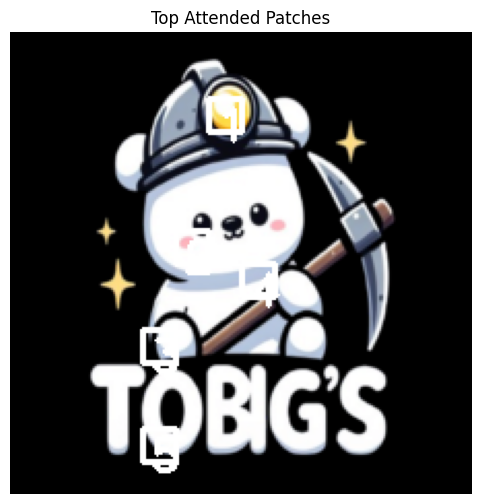

In [17]:
# Attention이 높은 patch 위치를 간단히 확인해보기
top_k = 5
flat_indices = np.argsort(mask.ravel())[::-1][:top_k]
patch_h = H // grid_size
patch_w = W // grid_size

boxed_img = (img * 255).astype(np.uint8).copy()
positions = []

for rank, flat_idx in enumerate(flat_indices, start=1):
    row = int(flat_idx // grid_size)
    col = int(flat_idx % grid_size)
    positions.append((row, col))

    x1, y1 = col * patch_w, row * patch_h
    x2 = min((col + 1) * patch_w, W - 1)
    y2 = min((row + 1) * patch_h, H - 1)

    cv2.rectangle(boxed_img, (x1, y1), (x2, y2), (255, 255, 255), 2)
    cv2.putText(boxed_img, str(rank), (x1 + 4, y1 + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

print("attention이 높은 상위 patch 위치(row, col):", positions)

plt.figure(figsize=(6, 6))
plt.imshow(boxed_img)
plt.title("Top Attended Patches")
plt.axis("off")
plt.show()